In [ ]:
"""
my Stacked: regression example by Stacked
"""

'\nmy Stacked: regression example by Stacked\n'

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.datasets import fetch_california_housing
from sklearn.datasets import make_friedman1  # also 2, 3
from sklearn.model_selection import train_test_split, KFold
from sklearn.utils import resample
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn import metrics


In [ ]:
# Dataset
[X, y] = fetch_california_housing(return_X_y=True)

Xtr, Xts, ytr, yts = train_test_split(X, y, test_size=0.3)

In [ ]:
print(Xtr.shape)
print(ytr.shape)

(14448, 8)
(14448,)


In [ ]:
max_depth = None
metric = metrics.mean_squared_error
# metric = metrics.r2_score

# Baseline
dt = DecisionTreeRegressor(max_depth=max_depth, random_state=0)
dt.fit(Xtr, ytr)
yp = dt.predict(Xts)
print('Res:', metric(yts, yp))

# Classifiers list
rlev1 = [ DecisionTreeRegressor(max_depth=max_depth),
          BayesianRidge(),
          Lasso() ]

T = len(rlev1)  # number of models in ensemble

Res: 0.5095366015606427


In [ ]:
#%% Train models
# Use KFold to create a kfold object, then use kf.split to
# generate the indexes for the train and test sets. Then train
# - Train models using the kfold training sets.
# - Predict on kfold test sets
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html#sklearn.model_selection.KFold

kf = KFold()
y_hat_all = np.zeros((len(ytr), T))

for itrain, itest in kf.split(Xtr):
    for t, c in enumerate(rlev1):
        print(t)
        c.fit(Xtr[itrain], ytr[itrain])
        y_hat_all[itest,t] = c.predict(Xtr[itest])

0
1
2
0
1
2
0
1
2
0
1
2
0
1
2


In [ ]:
# Aggregating
# Predict on all the test set with each model.

yts_hat = np.zeros((len(yts),len(rlev1)))
for t, c in enumerate(rlev1):
    print(t)
    yts_hat[:,t] = c.predict(Xts)

0
1
2


0.5758813566385982
0.5150352651770224
0.9540631231072731


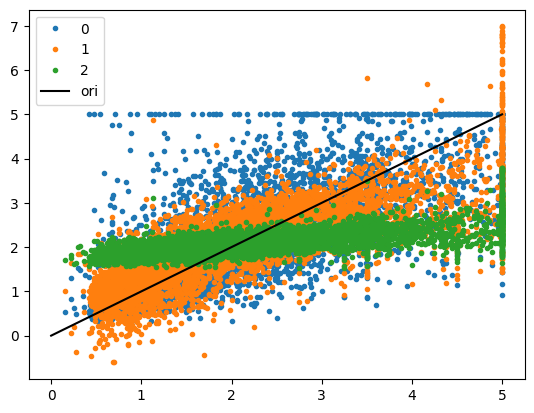

In [ ]:
plt.plot(yts,yts_hat[:,0],'.')
plt.plot(yts,yts_hat[:,1],'.')
plt.plot(yts,yts_hat[:,2],'.')
plt.plot([0,max(yts)],[0,max(yts)],'k-')
plt.legend(['0','1','2','ori'])

print(np.mean((yts-yts_hat[:,0])**2))
print(np.mean((yts-yts_hat[:,1])**2))
print(np.mean((yts-yts_hat[:,2])**2))

0.4657282706187096


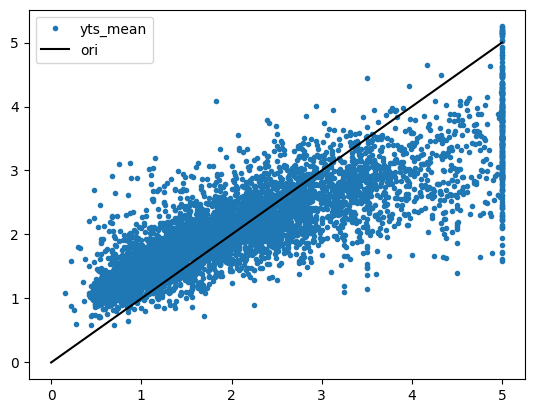

In [ ]:
# Aggregate the predictions.

# Mean
yts_mean = np.mean(yts_hat,axis=1)
plt.plot(yts,yts_mean,'.')
plt.plot([0,max(yts)],[0,max(yts)],'k-')
plt.legend(['yts_mean','ori'])

print(np.mean((yts-yts_mean)**2))


0.16122015279678864


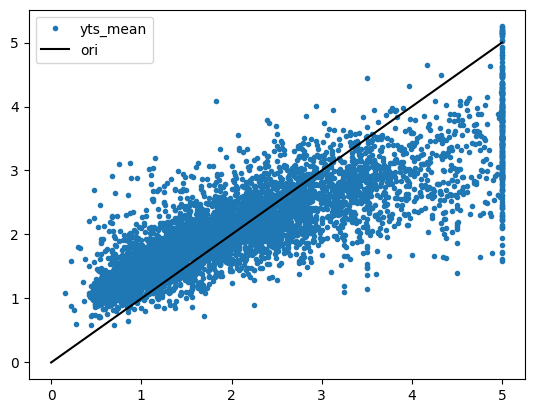

In [ ]:
# Median
yts_median = np.mean(yts_hat,axis=1)
plt.plot(yts,yts_median,'.')
plt.plot([0,max(yts)],[0,max(yts)],'k-')
plt.legend(['yts_mean','ori'])

print(np.median((yts-yts_median)**2))


0.24821005634155913


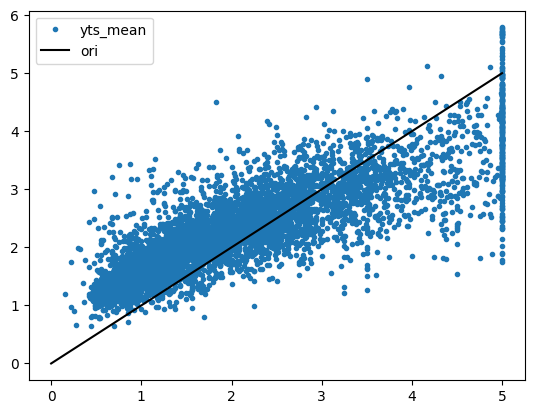

In [ ]:
# Weighted Mean

E0 = np.mean((yts-yts_hat[:,0])**2)
E1 = np.mean((yts-yts_hat[:,1])**2)
E2 = np.mean((yts-yts_hat[:,2])**2)

P0 = 1/E0
P1 = 1/E1
P2 = 1/E2

w0 = P0/(P0+P1+P2)
w1 = P1/(P0+P1+P2)
w2 = P2/(P0+P1+P2)

#w0 = np.exp(P0)/(np.exp(P0)+np.exp(P1)+np.exp(P2))
#w1 = np.exp(P1)/(np.exp(P0)+np.exp(P1)+np.exp(P2))
#w2 = np.exp(P2)/(np.exp(P0)+np.exp(P1)+np.exp(P2))

yts_hat_aux = yts_hat.copy()

yts_hat_aux[:,0] = w0*yts_hat[:,0]
yts_hat_aux[:,1] = w0*yts_hat[:,1]
yts_hat_aux[:,2] = w0*yts_hat[:,2]

yts_w_mean = np.sum(yts_hat_aux,axis=1)
plt.plot(yts,yts_w_mean,'.')
plt.plot([0,max(yts)],[0,max(yts)],'k-')
plt.legend(['yts_mean','ori'])

print(np.median((yts-yts_w_mean)**2))

In [ ]:
print(w0,w1,w2)
print(w0+w1+w2)

0.3674108160213268 0.4108166051529158 0.22177257882575746
1.0
